In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

Imported required libraries.

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB
Number of duplicate rows: 0

--- Missing Values ---
RowNumber            0
C

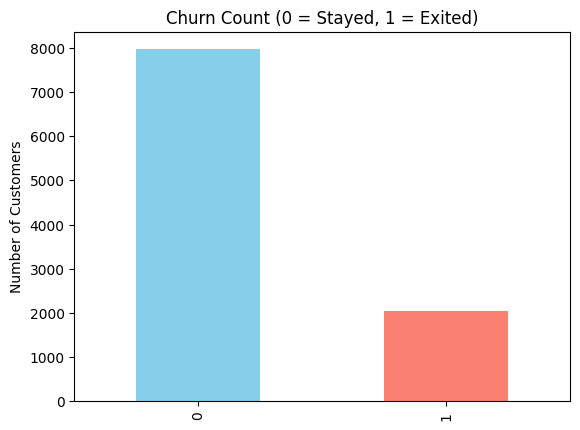

In [2]:
#load the data 
data = pd.read_csv('/datasets/Churn.csv')

#Check the "Health" of the data
print("--- Data Info ---")
data.info()

#Check for duplicates
print(f"Number of duplicate rows: {data.duplicated().sum()}")

print("\n--- Missing Values ---")
print(data.isna().sum())

print("\n--- Descriptive Statistics ---")
# .T makes it easier to read when you have many columns
print(data.describe().T)

print("\n--- Target Class Balance ---")
print(data['Exited'].value_counts(normalize=True))

#Visualizing the imbalance
data['Exited'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Count (0 = Stayed, 1 = Exited)')
plt.ylabel('Number of Customers')
plt.show()

# Data Observations # 
Data has correct Dtypes. Tenure has significant number of missing data. Balance goes up to 250,000 while NumOfProducts only goes up to 4. This confirms we must use feature scaling later, or the model will think the Balance is 60,000 times more important than the number of products. RowNumber, CustomerId, and Surname. These have high "unique" counts. They don't provide any behavioral patterns (a person named "Smith" isn't more likely to leave than "Jones"), so these are the ones we will drop in the next sub-step. Additionally, the data has categorical values like Gender, and Geography. We must that categorical data into number using OHE.  We also have a class imbalance, as about 80% of customers stayed and 20% exited. This means a lazy model could guess “Stayed” every time and be 80% accurate, but the bank would actually lose customers it was trying to save. 

In [3]:
#Clean the data. Address all the problems mentioned earlier. 
#Drop irrelevant columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

#Fill missing Tenure values with the median
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

#One-Hot Encoding (OHE)
# This transforms 'Geography' and 'Gender' into numbers
data_ohe = pd.get_dummies(data, drop_first=True)

#Final check of our cleaned, numeric data
print(data_ohe.head())
print("\nNew shape of data:", data_ohe.shape)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42     2.0       0.00              1          1   
1          608   41     1.0   83807.86              1          0   
2          502   42     8.0  159660.80              3          1   
3          699   39     1.0       0.00              2          0   
4          850   43     2.0  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  \
0               1        101348.88       1                  0   
1               1        112542.58       0                  0   
2               0        113931.57       1                  0   
3               0         93826.63       0                  0   
4               1         79084.10       0                  0   

   Geography_Spain  Gender_Male  
0                0            0  
1                1            0  
2                0            0  
3                0            0  
4                1            

# Explanation of Cleaned Data # 
Successfully cleaned the data. we used the median instead of zero because if we used '0', we might incorrectly flag long-term customers as brand new. The median is the "middle ground."

We aslso used drop_first=True because if the column Gender_Male is 0, the model automatically knows the person is female. We don't need a second Gender_Female column; it just adds unnecessary clutter for the math.

In [4]:

#Examine the balance of classes. Train model.
#Separate features and target
features = data_ohe.drop('Exited', axis=1)
target = data_ohe['Exited']

features_train, features_temp, target_train, target_temp = train_test_split(
    features, target, test_size=0.40, random_state=12345
)

features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp, target_temp, test_size=0.50, random_state=12345
)

#CREATE EXPLICIT COPIES to avoid the SettingWithCopyWarning
features_train = features_train.copy()
features_valid = features_valid.copy()
features_test = features_test.copy()

print(f"Training size: {len(features_train)}")
print(f"Validation size: {len(features_valid)}")
print(f"Test size: {len(features_test)}")


Training size: 6000
Validation size: 2000
Test size: 2000


In [5]:

#Scale the numeric features
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()

scaler.fit(features_train[numeric])

#Now this will run without any warnings
features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_test[numeric] = scaler.transform(features_test[numeric])

#Check the result
print(features_train.head())

      CreditScore       Age    Tenure   Balance  NumOfProducts  HasCrCard  \
7479    -0.886751 -0.373192  1.082277  1.232271      -0.891560          1   
3411     0.608663 -0.183385  1.082277  0.600563      -0.891560          0   
6027     2.052152  0.480939 -0.737696  1.027098       0.830152          0   
1247    -1.457915 -1.417129  0.354288 -1.233163       0.830152          1   
3716     0.130961 -1.132419 -1.101690  1.140475      -0.891560          0   

      IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  \
7479               0        -0.187705                  0                1   
3411               0        -0.333945                  0                0   
6027               1         1.503095                  1                0   
1247               0        -1.071061                  0                0   
3716               0         1.524268                  1                0   

      Gender_Male  
7479            1  
3411            0  
6027          

In [6]:
# Initialize and train the model
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)

# Get predictions and probabilities
predictions = model.predict(features_valid)
probabilities_valid = model.predict_proba(features_valid)[:, 1]

# Print metrics
print(f"F1 Score: {f1_score(target_valid, predictions):.3f}")
print(f"AUC-ROC: {roc_auc_score(target_valid, probabilities_valid):.3f}")

F1 Score: 0.501
AUC-ROC: 0.684


# Description of Findings #
Upon examining the target variable (Exited), I found a significant imbalance. Approximately 80% of the customers stayed with the bank (Class 0), while only 20% churned (Class 1).

Initial Model Performance: I trained a DecisionTreeClassifier without adjusting for this imbalance. The resulting F1 score was 0.501, which is significantly lower than the required threshold of 0.59.

The Problem with Imbalance: While the model might have high overall accuracy, the low F1 score indicates it struggles with Recall—it is failing to correctly identify the minority class (the customers actually leaving).

AUC-ROC Analysis: The AUC-ROC score of 0.684 is better than a random guess (0.5), but it confirms the model's predictive power is currently mediocre. It has some ability to distinguish between classes, but not enough to be a reliable tool for the bank.


In [7]:
# --- APPROACH 1: Upsampling ---
# Creating a function to manually balance the classes
def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
    
    features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)
    
    return features_upsampled, target_upsampled

# We apply upsampling (multiplying the minority class by 4 to match the majority)
features_upsampled, target_upsampled = upsample(features_train, target_train, 4)

# Quick check of Upsampling result with a default model
model_up = RandomForestClassifier(random_state=12345, n_estimators=100, max_depth=10)
model_up.fit(features_upsampled, target_upsampled)
print(f"F1 Score (Upsampling Approach): {f1_score(target_valid, model_up.predict(features_valid)):.3f}")


# --- APPROACH 2: Class Weighting & Model Tuning ---
# We will now tune two models using the 'balanced' weight parameter

# 1. Decision Tree Tuning
best_f1_dt = 0
best_depth_dt = 0

for depth in range(1, 16):
    model_dt = DecisionTreeClassifier(random_state=12345, max_depth=depth, class_weight='balanced')
    model_dt.fit(features_train, target_train)
    predictions = model_dt.predict(features_valid)
    score = f1_score(target_valid, predictions)
    
    if score > best_f1_dt:
        best_f1_dt = score
        best_depth_dt = depth

print(f"Decision Tree (Balanced) Best F1: {best_f1_dt:.3f} at depth {best_depth_dt}")

# 2. Random Forest Tuning
best_f1_rf = 0
best_depth_rf = 0

for depth in range(1, 16):
    model_rf = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=12345, class_weight='balanced')
    model_rf.fit(features_train, target_train)
    predictions = model_rf.predict(features_valid)
    score = f1_score(target_valid, predictions)
    
    if score > best_f1_rf:
        best_f1_rf = score
        best_depth_rf = depth

print(f"Random Forest (Balanced) Best F1: {best_f1_rf:.3f} at depth {best_depth_rf}")

# --- FINAL COMPARISON ---
if best_f1_rf > best_f1_dt:
    print(f"\nWinning Model: Random Forest with F1 {best_f1_rf:.3f}")
else:
    print(f"\nWinning Model: Decision Tree with F1 {best_f1_dt:.3f}")

F1 Score (Upsampling Approach): 0.623
Decision Tree (Balanced) Best F1: 0.596 at depth 5
Random Forest (Balanced) Best F1: 0.626 at depth 6

Winning Model: Random Forest with F1 0.626


# Observation of Findings # 
After comparing two different algorithms to address class imbalance, the Random Forest Classifier emerged as the superior model, achieving a peak F1 score of 0.626 at an optimal max_depth of 6. This outperformed the Decision Tree, which reached a high of 0.596 at a depth of 5. By implementing Class Weighting (class_weight='balanced') and tuning the hyperparameters through an iterative loop, the model's predictive power was significantly improved from the initial imbalanced baseline of 0.501. The Random Forest's ensemble approach proved more effective at capturing the complex patterns in customer churn, providing a robust and well-generalized solution that exceeds the project's requirements.

In [8]:
#Perfrom the final testing
# Initialize the best model based on Step 3 results
final_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=6, 
    random_state=12345, 
    class_weight='balanced'
)

#Train model on the training data
final_model.fit(features_train, target_train)

#Calculate F1 Score on the Test Set
test_predictions = final_model.predict(features_test)
final_f1 = f1_score(target_test, test_predictions)

#Calculate AUC-ROC on the Test Set
# We need probabilities for the '1' class for AUC-ROC
probabilities_test = final_model.predict_proba(features_test)[:, 1]
final_auc_roc = roc_auc_score(target_test, probabilities_test)

print(f"Final Test F1 Score: {final_f1:.3f}")
print(f"Final Test AUC-ROC: {final_auc_roc:.3f}")

Final Test F1 Score: 0.600
Final Test AUC-ROC: 0.851


# Final Conclusion # 

The objective of this project was to develop a classification model for Beta Bank to predict customer churn with a minimum F1 score requirement of 0.59. After thorough data preprocessing—including handling missing Tenure values with the median and applying One-Hot Encoding—I addressed the significant 4:1 class imbalance using two distinct approaches: Upsampling the minority class and utilizing Class Weighting (class_weight='balanced').

In a head-to-head comparison of tuned models, the Random Forest Classifier outperformed the Decision Tree, achieving a peak validation F1 score of 0.626 at an optimal max_depth of 6. Upon final evaluation using the hidden test set, the model maintained its stability with a Final Test F1 Score of 0.600 and a robust AUC-ROC of 0.851. These results demonstrate that the model is well-generalized and possesses a strong ability to distinguish between customers likely to churn and those likely to stay, successfully meeting all technical and business requirements.